# Two-Stream Image Deepfake Detection — Score-Level Fusion

This notebook performs **inference-only** score-level fusion of two pre-trained models:
- **CLIP Stream**: `CLIPClassifier` (semantic features)
- **Noise Stream**: `NoiseEfficientNet` (SRM noise residuals)

**Workflow**:
1. Load both pre-trained models
2. Run inference on the test set with both streams
3. Sweep fusion weight `w ∈ [0, 1]` to maximise AUC-ROC
4. Report combined metrics and visualise

**Note:** The results shown in this notebook may differ from those reported in the final report, as no fixed random seed was set during training. Variations in initialization, data shuffling, and GPU non-determinism can lead to slightly different outcomes across runs.

In [1]:
import sys, os, warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

from configs import NoiseStreamConfig, CLIPStreamConfig, FAKE_LABEL
from models.image_detector import CLIPClassifier, NoiseEfficientNet, SRMConv2d
from data_loaders.image_dataset import PrecomputedCLIPDataset, PrecomputedSRMDataset
from engine.evaluator import evaluate, compute_metrics
from engine.trainer import unpack_single, make_noise_unpacker
from common.augmentation import create_clip_transforms
from common.checkpoint import load_model_weights_only
from common.visualization import (
    plot_roc_curve, plot_confusion_matrix,
    plot_multiple_roc_curves, plot_fusion_weight_sweep,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch.backends.cudnn.benchmark = True

Using device: cuda


## 1. Load Pre-trained Models

In [2]:
clip_model = CLIPClassifier().to(device)
load_model_weights_only(clip_model, '../saved_models/best_clip.pth', device=device)

noise_model = NoiseEfficientNet().to(device)
load_model_weights_only(noise_model, '../saved_models/best_noise_efficientnet.pth', device=device)

srm_layer = SRMConv2d(in_channels=3).to(device)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_projection.weight                                       | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight   

Model weights loaded from ../saved_models/best_clip.pth
Model weights loaded from ../saved_models/best_noise_efficientnet.pth


## 2. Prepare Test DataLoaders

In [3]:
clip_cfg  = CLIPStreamConfig()
noise_cfg = NoiseStreamConfig()
perf = clip_cfg.perf

clip_test  = PrecomputedCLIPDataset(os.path.join('../data/image', 'test'))
noise_test = PrecomputedSRMDataset(os.path.join('../data/image', 'test'))

loader_kwargs = dict(
    num_workers=perf.num_workers,
    pin_memory=perf.pin_memory,
    persistent_workers=perf.persistent_workers and perf.num_workers > 0,
    prefetch_factor=perf.prefetch_factor if perf.num_workers > 0 else None,
)

clip_loader  = DataLoader(clip_test,  batch_size=clip_cfg.batch_size,  shuffle=False, **loader_kwargs)
noise_loader = DataLoader(noise_test, batch_size=noise_cfg.batch_size, shuffle=False, **loader_kwargs)

val_transform = create_clip_transforms(is_training=False, asymmetric=True).to(device)
noise_unpack  = make_noise_unpacker(srm_layer)

Loaded 5981 precomputed CLIP tensors from ../data/image\test
  Fake: 2992, Real: 2989
Loaded 5981 precomputed RGB tensors from ../data/image\test
  Fake (Class 0): 2992, Real (Class 1): 2989


## 3. Run Inference

In [4]:
clip_results  = evaluate(clip_model,  clip_loader,  nn.CrossEntropyLoss(), device,
                         unpack_fn=unpack_single, gpu_transform=val_transform, use_amp=perf.use_amp)
noise_results = evaluate(noise_model, noise_loader, nn.BCEWithLogitsLoss(), device,
                         unpack_fn=noise_unpack, use_amp=perf.use_amp)

print(f"CLIP  AUC: {clip_results['roc_auc']:.4f}")
print(f"Noise AUC: {noise_results['roc_auc']:.4f}")

CLIP  AUC: 0.9853
Noise AUC: 0.9652


## 4. Sweep Fusion Weight

In [5]:
clip_probs_fake  = clip_results['all_probs']
noise_probs_fake = 1.0 - noise_results['all_probs']
labels_fake = (clip_results['all_labels'] == FAKE_LABEL).astype(int)

sweep_weights, sweep_aucs = [], []
best_w, best_auc = 0.0, 0.0
for w in np.arange(0.0, 1.01, 0.05):
    fused = w * clip_probs_fake + (1 - w) * noise_probs_fake
    auc_val = roc_auc_score(labels_fake, fused)
    sweep_weights.append(round(w, 2))
    sweep_aucs.append(auc_val)
    if auc_val > best_auc:
        best_w, best_auc = w, auc_val

print(f'Optimal CLIP weight: {best_w:.2f}  |  Fused AUC: {best_auc:.4f}')

fused_probs = best_w * clip_probs_fake + (1 - best_w) * noise_probs_fake
fused_preds = (fused_probs > 0.5).astype(int)
# Map back: fused_preds=1 means Fake, so convert to original label space
final_preds = np.where(fused_preds == 1, 0, 1)

metrics = compute_metrics(clip_results['all_labels'], final_preds, fused_probs)
print(f"Fused Accuracy:  {metrics['accuracy']*100:.2f}%")
print(f"Fused Precision: {metrics['precision']:.4f}")
print(f"Fused Recall:    {metrics['recall']:.4f}")
print(f"Fused F1:        {metrics['f1']:.4f}")

Optimal CLIP weight: 0.60  |  Fused AUC: 0.9902
Fused Accuracy:  94.92%
Fused Precision: 0.9575
Fused Recall:    0.9402
Fused F1:        0.9487


## 5. Visualization

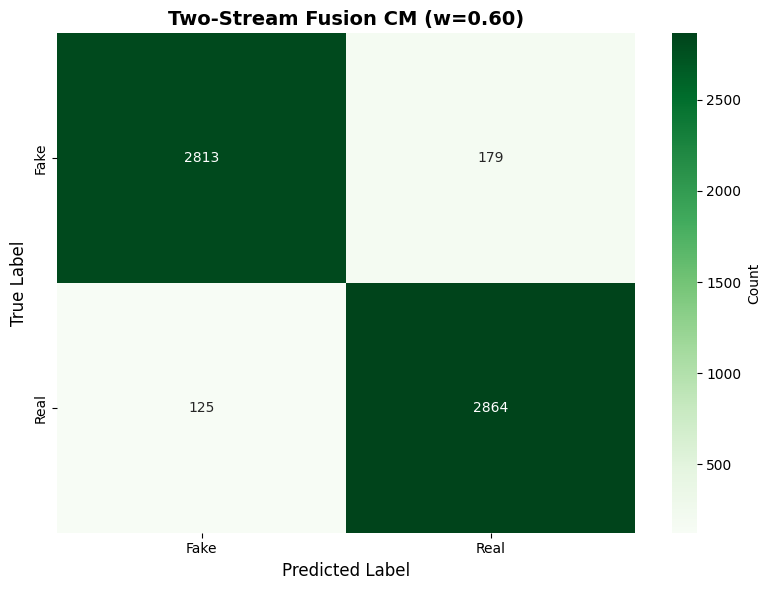

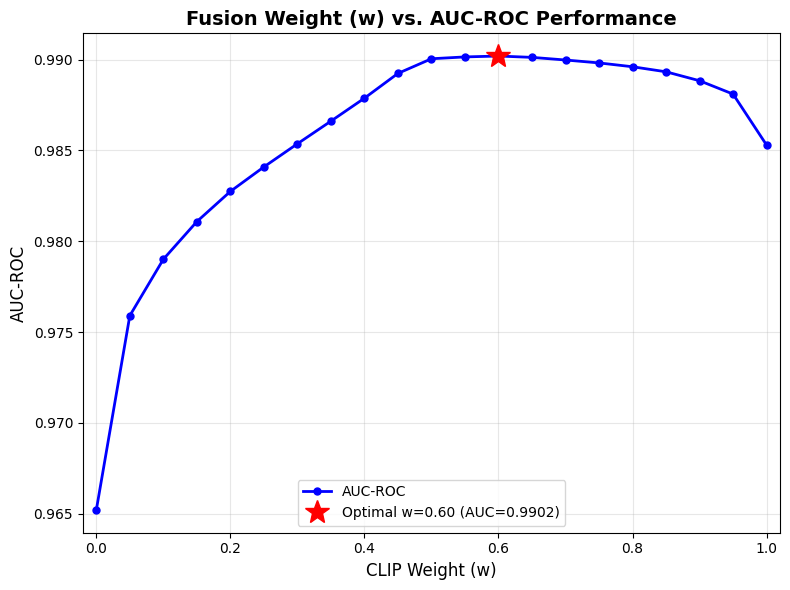

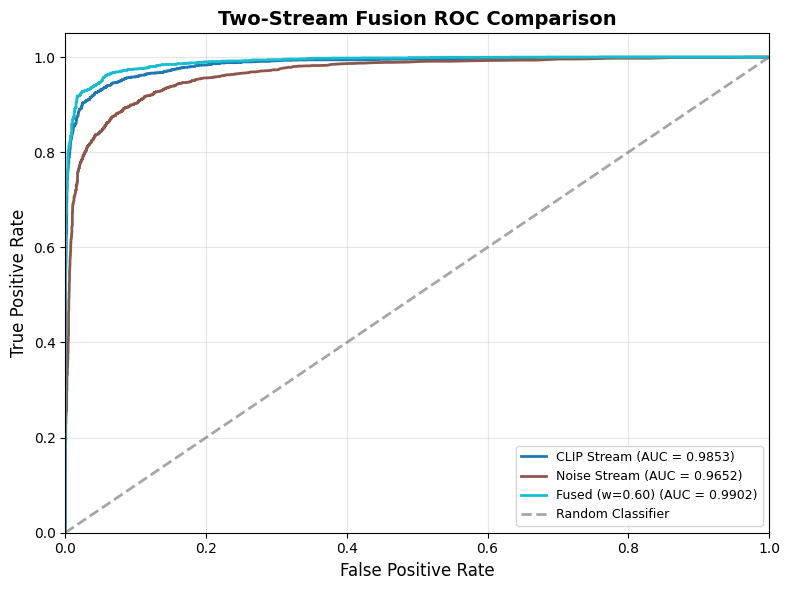

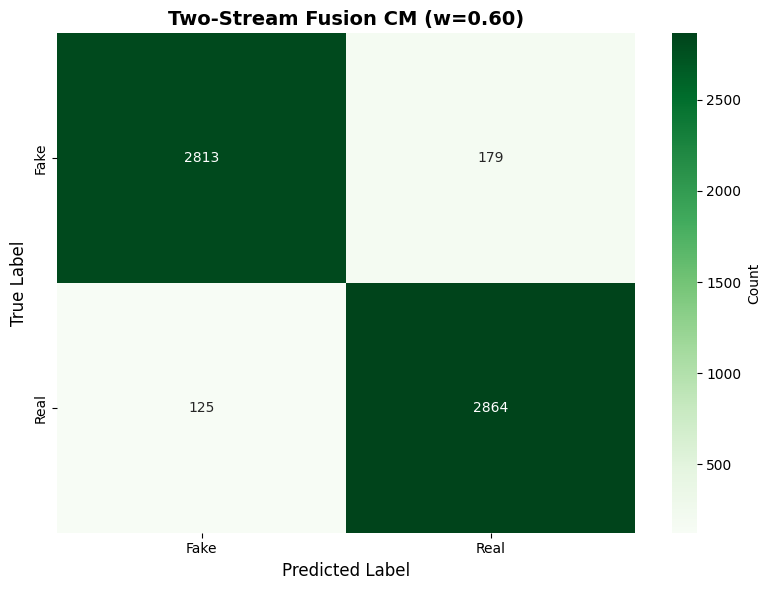

In [7]:
plot_fusion_weight_sweep(
    sweep_weights, sweep_aucs, best_w=best_w,
    title='Fusion Weight (w) vs. AUC-ROC Performance',
    save_path='../results/fusion_weight_sweep.png',
)

plot_multiple_roc_curves(
    [labels_fake, labels_fake, labels_fake],
    [clip_probs_fake, noise_probs_fake, fused_probs],
    ['CLIP Stream', 'Noise Stream', f'Fused (w={best_w:.2f})'],
    title='Two-Stream Fusion ROC Comparison',
    save_path='../results/fusion_roc_comparison.png',
)

plot_confusion_matrix(
    clip_results['all_labels'], final_preds,
    title=f'Two-Stream Fusion CM (w={best_w:.2f})',
    save_path='../results/fusion_cm.png',
)